In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [ ]:
df=pd.read_csv("HR-Employee-Attrition.csv")
print(df.shape)
print(df.head())

(1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

In [ ]:
print(df.columns.tolist())
print(df["Attrition"].value_counts())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [ ]:
overall=df['Attrition'].value_counts(normalize=True)*100
print(f"overall Attrition Rate: {overall['Yes']:.1f}%")


overall Attrition Rate: 16.1%


In [ ]:
dept_attrition = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
dept_attrition.columns = ['Department', 'Attrition_Rate']
print(dept_attrition)

               Department  Attrition_Rate
0         Human Resources       19.047619
1  Research & Development       13.839750
2                   Sales       20.627803


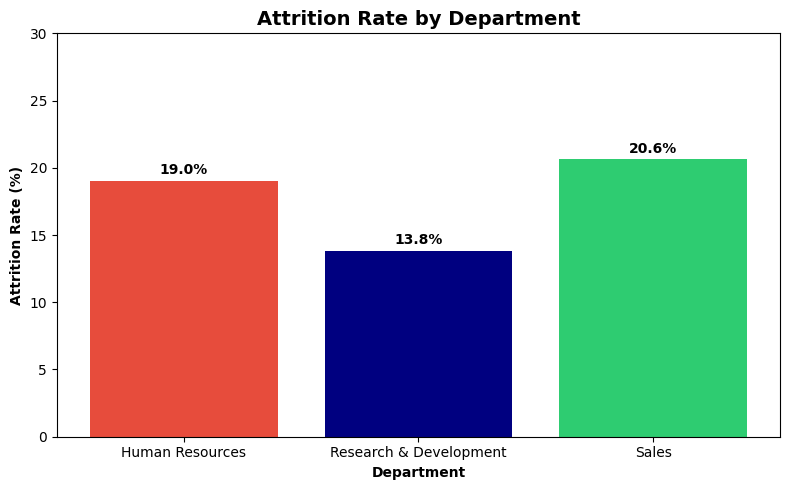

In [41]:
plt.figure(figsize=(8,5))
plt.bar(dept_attrition['Department'], dept_attrition['Attrition_Rate'], color=['#e74c3c','#000080','#2ecc71'])
plt.title("Attrition Rate by Department", fontsize=14,fontweight="bold")
plt.xlabel('Department', fontweight='bold')
plt.ylabel('Attrition Rate (%)', fontweight='bold')
plt.ylim(0,30)
for i, v in enumerate(dept_attrition['Attrition_Rate']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_department.png',dpi=150)
plt.show()

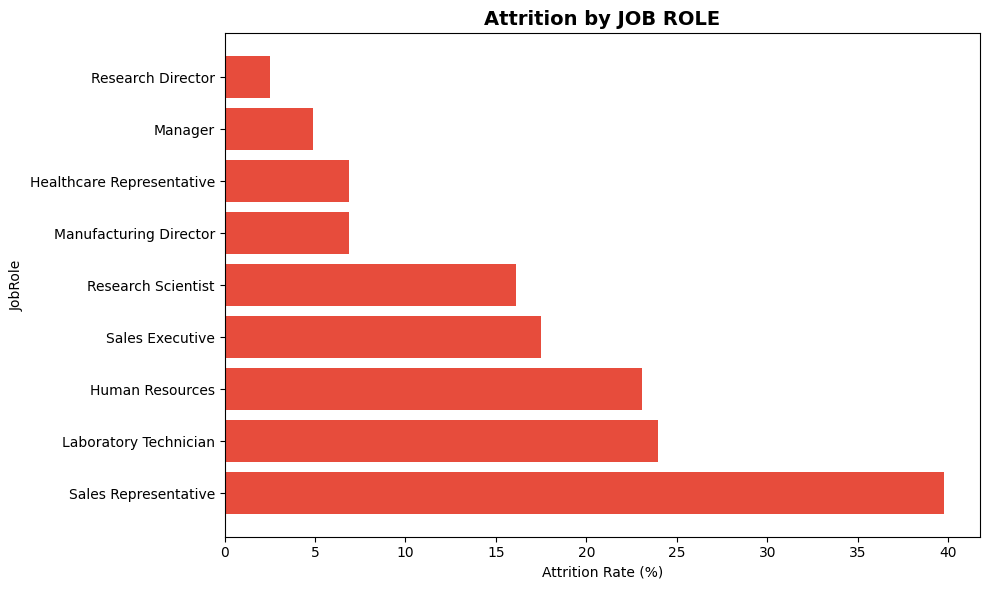

In [79]:
role_attrition = df.groupby('JobRole')["Attrition"].apply(
    lambda x:(x =='Yes').sum()/ len(x)*100
).reset_index()
role_attrition.columns= ['JobRole', 'Attrition_Rate']
role_attrition= role_attrition.sort_values('Attrition_Rate', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(role_attrition['JobRole'], role_attrition['Attrition_Rate'], color='#e74c3c')
plt.title("Attrition by JOB ROLE", fontsize=14, fontweight="bold")
plt.xlabel('Attrition Rate (%)')
plt.ylabel('JobRole')
plt.tight_layout()
plt.savefig('chart2_jobrole.png',dpi=150)
plt.show()

  Tenure_Group  Attrition_Rate
0      0-2 yrs       28.859060
1      3-5 yrs       13.824885
2     6-10 yrs       12.276786
3    11-20 yrs        6.666667
4      20+ yrs       12.121212


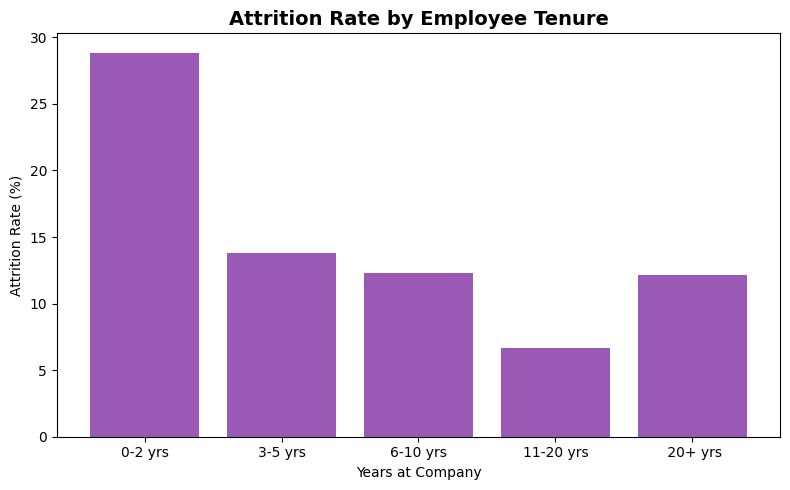

In [84]:
bins=[0,2,5,10,20,40]
labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', ' 20+ yrs']
df['Tenure_Group']= pd.cut(df['YearsAtCompany'], bins=bins, labels=labels)

tenure_attrition=df.groupby('Tenure_Group', observed=True)['Attrition'].apply(
    lambda x: ( x=='Yes').sum()/ len(x)*100
).reset_index()
tenure_attrition.columns=['Tenure_Group', 'Attrition_Rate']
print(tenure_attrition)


plt.figure(figsize=(8,5))
plt.bar(tenure_attrition['Tenure_Group'], tenure_attrition['Attrition_Rate'], color='#9b59b6')
plt.title('Attrition Rate by Employee Tenure', fontsize=14, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
plt.savefig('chart3_tenure.png',dpi=150)
plt.show()

In [1]:
observations = """
OBSERVATIONS
============

1. Sales has the highest attrition at 20.6%, nearly double R&D's 13.8%.
   This suggests sales roles face higher burnout or better outside opportunities.

2. New employees (0-2 years) have the highest attrition at 28.9%,
   meaning nearly 1 in 3 new hires leaves early. Onboarding is a critical problem.

3. Employees with 11-20 years of experience show the lowest attrition (6.7%),
   suggesting long-tenured employees are the most loyal and stable.
"""
print(observations)


OBSERVATIONS

1. Sales has the highest attrition at 20.6%, nearly double R&D's 13.8%.
   This suggests sales roles face higher burnout or better outside opportunities.

2. New employees (0-2 years) have the highest attrition at 28.9%,
   meaning nearly 1 in 3 new hires leaves early. Onboarding is a critical problem.

3. Employees with 11-20 years of experience show the lowest attrition (6.7%),
   suggesting long-tenured employees are the most loyal and stable.

